# Percolation Benchmark Analysis

This notebook is a thin interactive wrapper around `percolation_uart.analysis`.

It keeps the SQLite loading and plotting logic in the analysis module, so the notebook can stay lightweight while you inspect sessions, select a run, and render the standard plots inline.

In [32]:
from __future__ import annotations

import sys
import tempfile
from pathlib import Path

from IPython.display import Image, display

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'python' / 'percolation_uart' / 'analysis.py').exists():
            return candidate
    raise FileNotFoundError('could not locate repository root')

repo_root = find_repo_root()
python_dir = repo_root / 'python'
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))

from percolation_uart import analysis

db_path = analysis.DEFAULT_DB
plot_dir = repo_root / 'python' / 'output' / 'notebook_analysis'
plot_dir.mkdir(parents=True, exist_ok=True)
db_path, plot_dir

(PosixPath('/home/alessio/ssd_data/Alessio/uni_magistrale/Programmable_Hardware_Devices/FPGA-project/python/output/benchmark.sqlite3'),
 PosixPath('/home/alessio/ssd_data/Alessio/uni_magistrale/Programmable_Hardware_Devices/FPGA-project/python/output/notebook_analysis'))

In [33]:
conn = analysis._connect(db_path)
try:
    sessions = analysis.list_sessions(conn)
    print(analysis.summarize_db(conn))
    print()
    for index, session in enumerate(sessions, start=1):
        payload = session.payload
        print(f'{index:2d}. session_id={session.session_id} created_at={session.created_at}')
        if 'config_hash' in payload:
            print(f'    config_hash={payload["config_hash"]}')
        if 'args' in payload and isinstance(payload['args'], dict):
            args = payload['args']
            print(f'    runs={args.get("runs")} repeats={args.get("repeats")} points={args.get("points")} steps={args.get("steps")}')
finally:
    conn.close()

sessions=64, summary_rows=208, raw_rows=6990, p_range=[0.5000, 0.7000]

 1. session_id=c6553639-8866-4929-a9a0-0a153be2954a created_at=2026-05-14T08:46:16.634167+00:00
    config_hash=cf225c3816cca6cac759b5ddfda6884b2047ba089bd797a2abe9c370fbc4644e
    runs=500 repeats=2 points=5 steps=64
 2. session_id=2ae873ee-d0de-46e4-a82c-ca2bd696fd5d created_at=2026-05-14T09:44:16.118397+00:00
    config_hash=533e13096aab4d4384a371ec898f047d9b75c3e754abf4f3984e799b6c0a6e97
    runs=100000 repeats=100 points=40 steps=64
 3. session_id=63188a2d-60a7-4bc0-9176-774f781e3814 created_at=2026-05-14T10:51:05.619957+00:00
 4. session_id=4e4d1f6b-01c2-4157-97e9-589b3b89a12e created_at=2026-05-14T13:39:48.525143+00:00
 5. session_id=969e310f-07ed-4199-9999-cfc89fa1e314 created_at=2026-05-14T13:48:33.776234+00:00
 6. session_id=93971f90-4cd9-4057-92cb-8997243f72b2 created_at=2026-05-14T14:39:49.362028+00:00
 7. session_id=b4d6f24b-cb6c-4823-b523-676f6625dbd5 created_at=2026-05-14T14:43:22.385761+00:00
 8. se

In [34]:
selected_session_index = 8-1

conn = analysis._connect(db_path)
try:
    sessions = analysis.list_sessions(conn)
    if not sessions:
        raise RuntimeError(f'no sessions found in {db_path}')
    selected_session = sessions[selected_session_index]
    selected_session_id = selected_session.session_id
    summary_rows = analysis.load_summary_rows(conn, session_id=selected_session_id)
    raw_rows = analysis.load_raw_rows(conn, session_id=selected_session_id)
finally:
    conn.close()

print(f'selected_session_id={selected_session_id}')
print(f'selected_created_at={selected_session.created_at}')
print(f'summary_rows={len(summary_rows)} raw_rows={len(raw_rows)}')

selected_session_id=7c5e994b-cc93-41cd-a128-e449e2009b53
selected_created_at=2026-05-14T15:28:40.433064+00:00
summary_rows=10 raw_rows=1000


In [35]:
import matplotlib.pyplot as plt

runs = float(selected_session.payload.get('args', {}).get('runs', raw_rows[0]['runs']))
steps = float(selected_session.payload.get('args', {}).get('steps', raw_rows[0]['steps']))
ideal_core_cycles_per_run = steps * 3.0 + 3.0
wire_cycles_per_run = float(raw_rows[0]['uart_wire_s']) * 100_000_000.0 / runs

p_values = [float(row['p']) for row in summary_rows]
measured_cycles = [float(row['hw_latency_per_run_cycles']) for row in summary_rows]
core_est_cycles = [float(row['hw_core_latency_per_run_cycles_est']) for row in summary_rows]
uart_and_host_cycles = [value - ideal_core_cycles_per_run for value in measured_cycles]
wire_cycles = [wire_cycles_per_run for _ in p_values]
residual_cycles = [value - wire_cycles_per_run for value in uart_and_host_cycles]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(p_values, measured_cycles, 'o-', label='Measured latency per run')
axes[0].plot(p_values, core_est_cycles, 's-', label='Core estimate from benchmark')
axes[0].axhline(ideal_core_cycles_per_run, color='black', linestyle='--', label=f'Ideal core budget ~{ideal_core_cycles_per_run:.0f} cycles/run')
axes[0].set_ylabel('Cycles per run')
axes[0].set_title('Latency decomposition for the selected session')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(p_values, uart_and_host_cycles, 'o-', label='Measured overhead beyond ideal core')
axes[1].plot(p_values, wire_cycles, 's-', label='Theoretical UART wire time per run')
axes[1].plot(p_values, residual_cycles, '^-', label='Overhead after subtracting wire time')
axes[1].set_xlabel('Occupation probability p')
axes[1].set_ylabel('Cycles per run')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'ideal_core_cycles_per_run={ideal_core_cycles_per_run:.3f}')
print(f'wire_cycles_per_run={wire_cycles_per_run:.3f}')
print(f'measured_minus_ideal_core_first_p={uart_and_host_cycles[0]:.3f}')
print(f'measured_minus_ideal_core_minus_wire_first_p={residual_cycles[0]:.3f}')

ideal_core_cycles_per_run=3072.000
wire_cycles_per_run=4.234
measured_minus_ideal_core_first_p=1033.579
measured_minus_ideal_core_minus_wire_first_p=1029.345


/tmp/ipykernel_229888/2573493522.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


dashboard.png


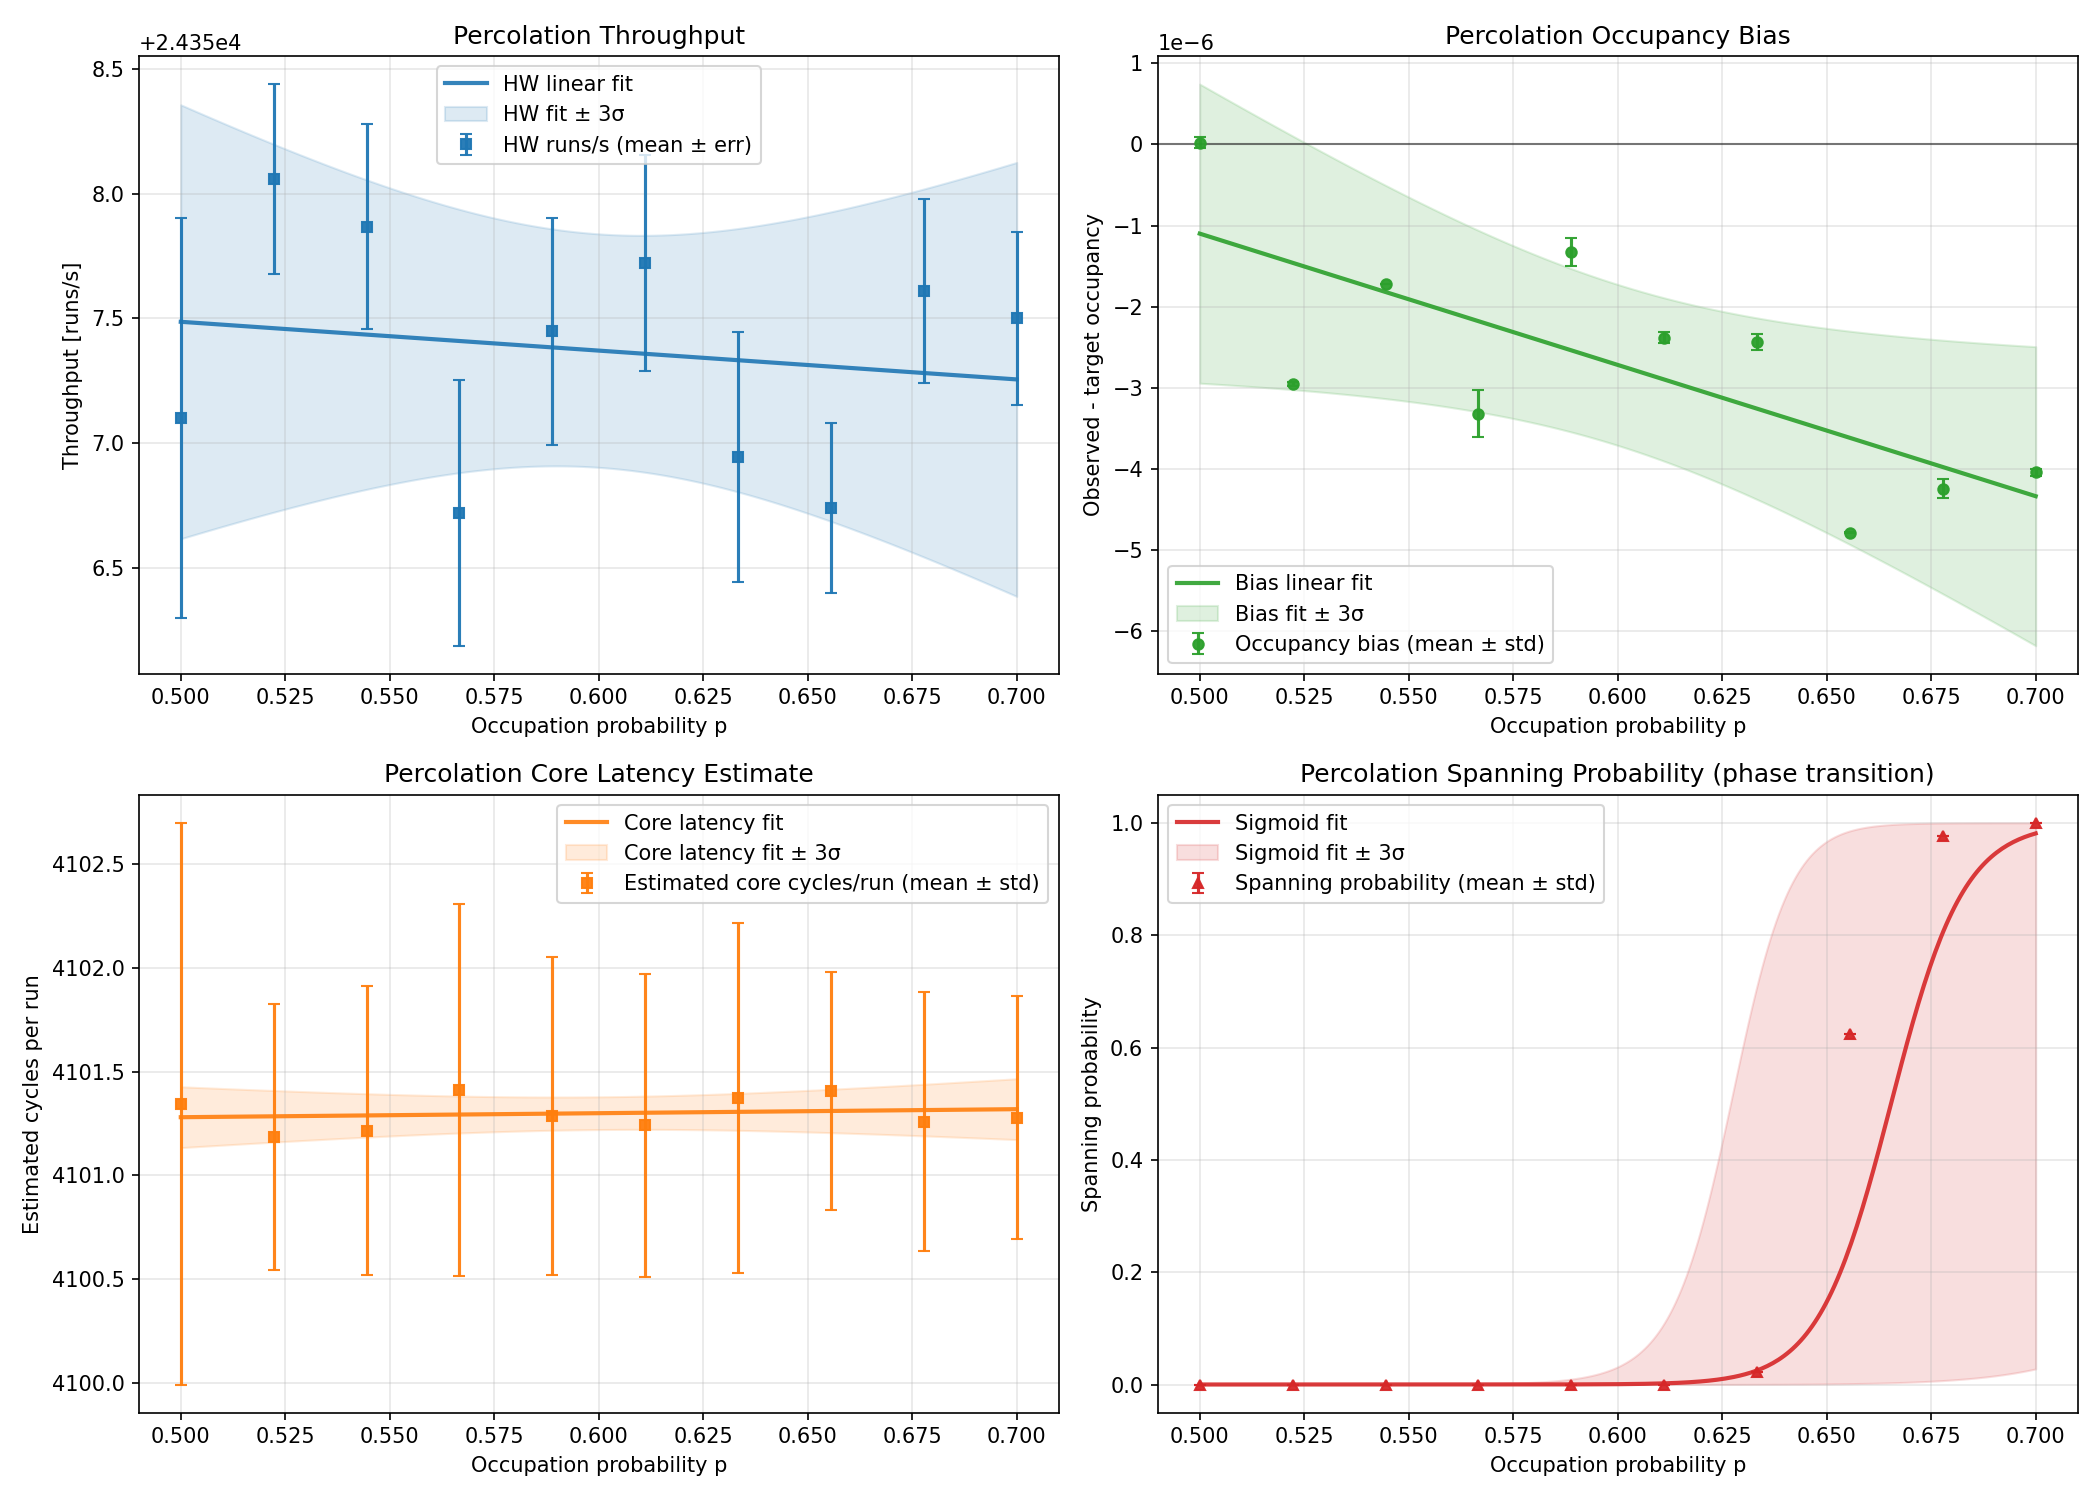

front_density.png


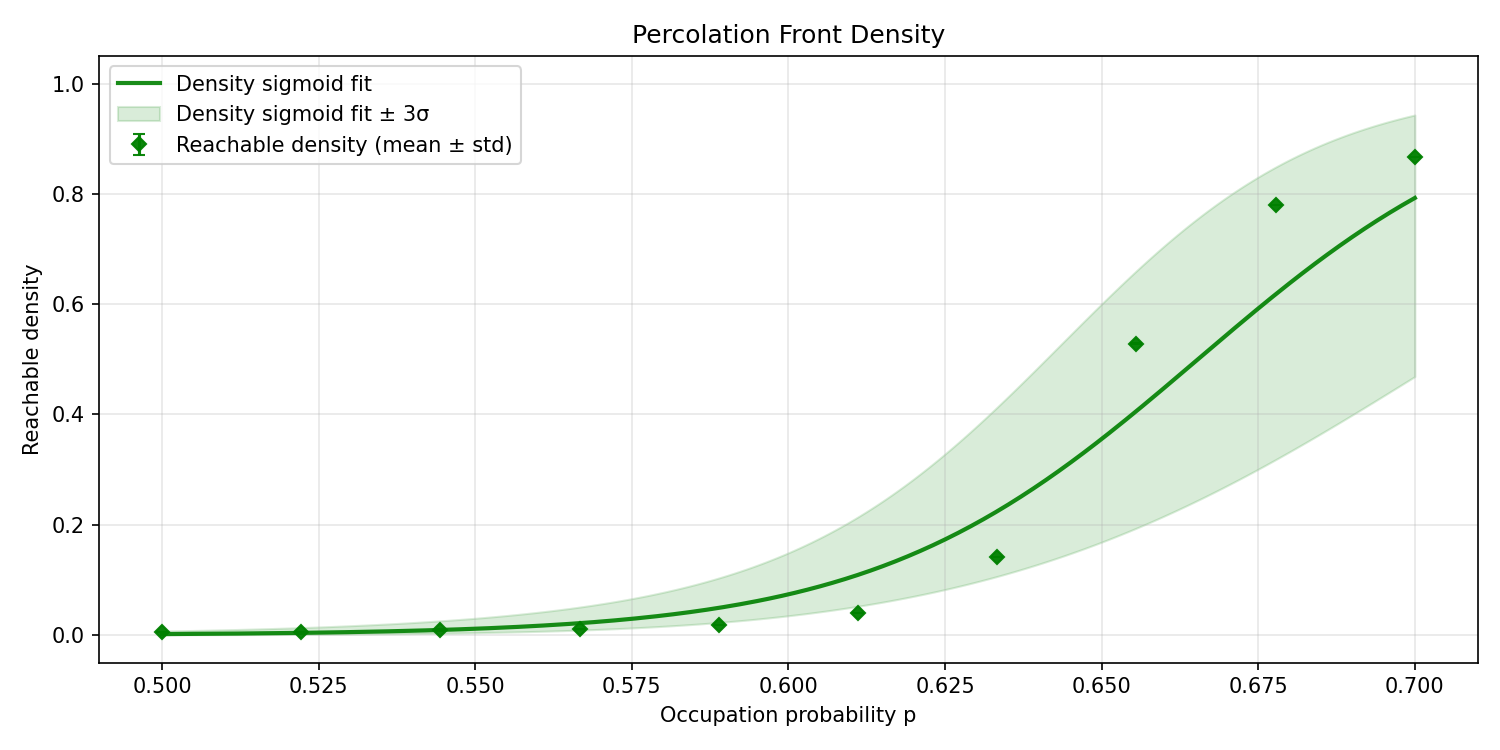

cluster_mass.png


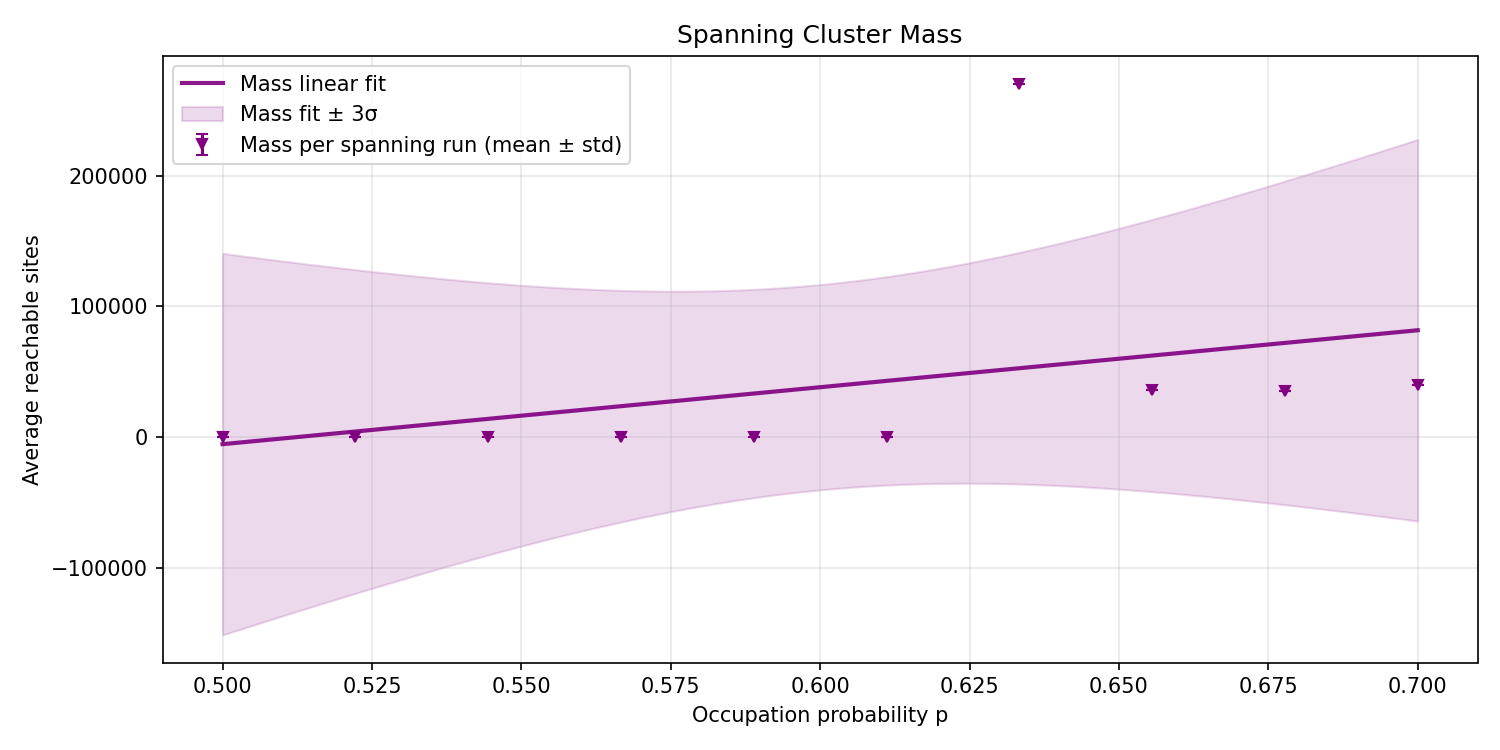

occupancy_bias.png


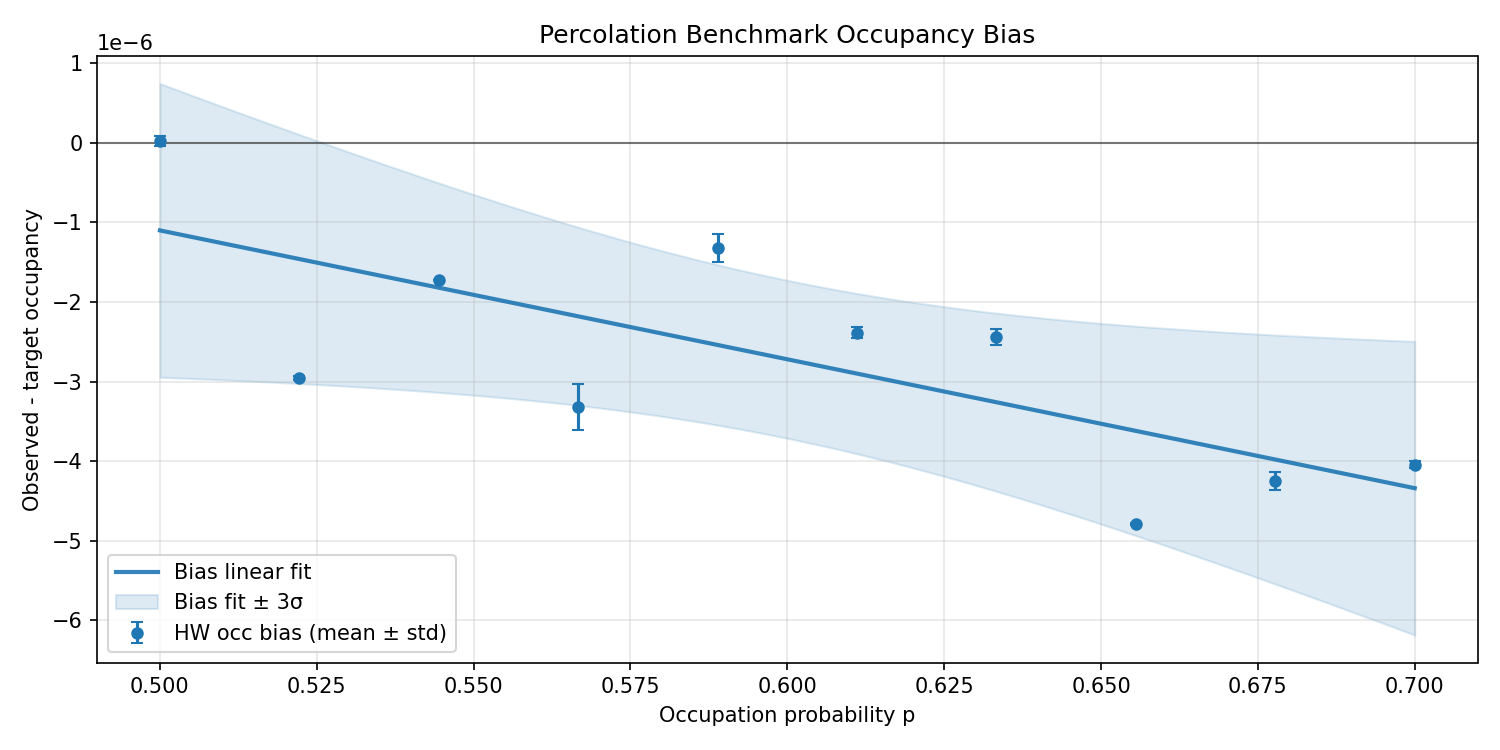

core_latency.png


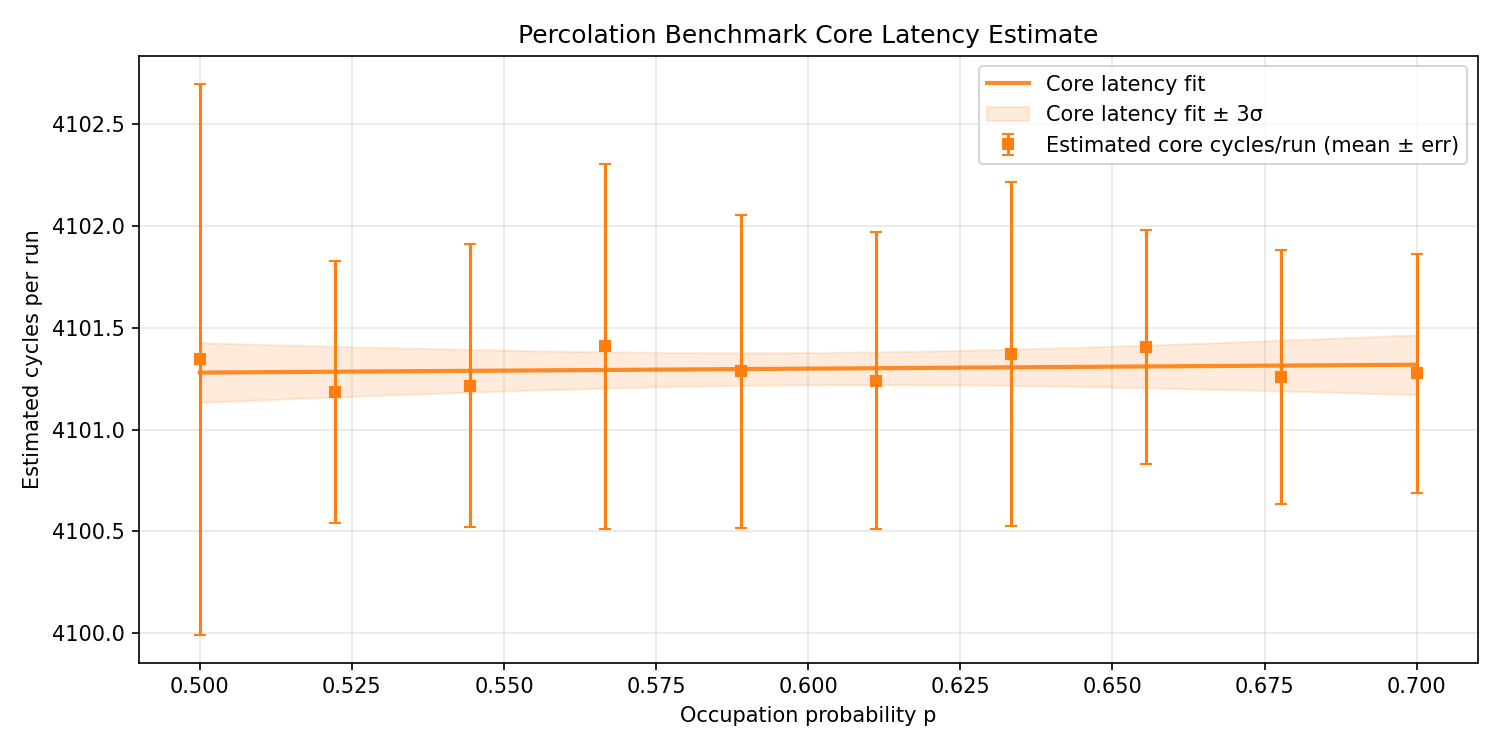

spanning_probability.png


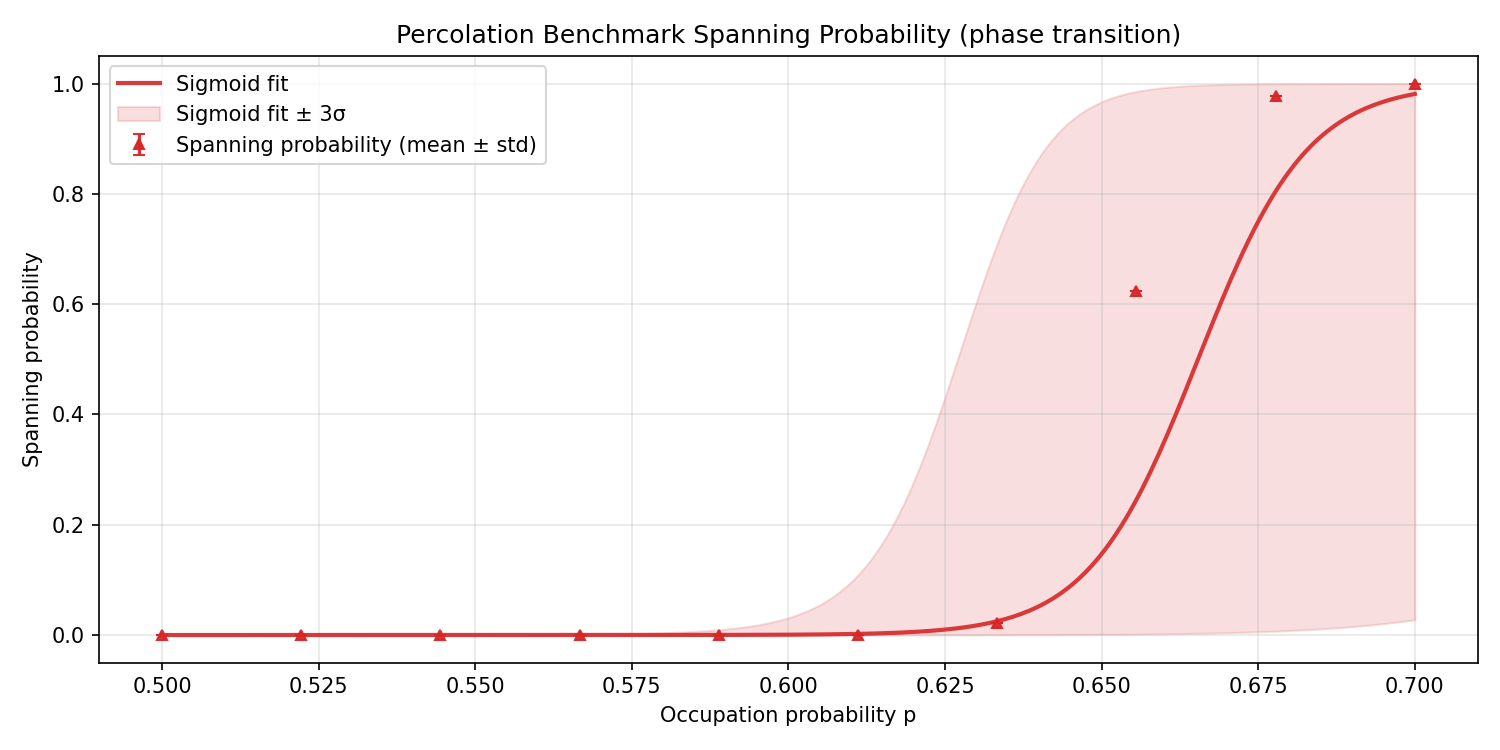

In [36]:
def render_png(path: Path) -> None:
    if not path.exists():
        print(f'missing: {path}')
        return
    display(Image(filename=str(path)))

session_plot_dir = plot_dir / selected_session_id
session_plot_dir.mkdir(parents=True, exist_ok=True)

analysis.plot_dashboard(summary_rows, raw_rows, session_plot_dir / 'dashboard.png')
analysis.plot_front_density(raw_rows, session_plot_dir / 'front_density.png')
analysis.plot_cluster_mass(raw_rows, session_plot_dir / 'cluster_mass.png')
analysis.plot_occupancy_bias(raw_rows, session_plot_dir / 'occupancy_bias.png')
analysis.plot_core_latency(raw_rows, session_plot_dir / 'core_latency.png')
analysis.plot_spanning_probability(raw_rows, session_plot_dir / 'spanning_probability.png')

for filename in [
    'dashboard.png',
    'front_density.png',
    'cluster_mass.png',
    'occupancy_bias.png',
    'core_latency.png',
    'spanning_probability.png',
]:
    print(filename)
    render_png(session_plot_dir / filename)

## Optional batch view

Change `selected_session_index` and rerun the selection and rendering cells to inspect another benchmark session.

If you want to compare several sessions at once, keep the analysis logic in the module and use a small loop here to render one subdirectory per session.

## Sweep Session Explorer

This section inspects the recent latency sweep sessions collected with fixed probability `p = 0.60` and compares them by `steps_per_run` and `cfg_runs`.

It stays inside the notebook so the analysis logic remains in `percolation_uart.analysis` while the notebook only orchestrates filtering and plotting.

In [37]:
SWEEP_RUNS = {1, 4, 16, 64, 256, 1024, 4096, 16384, 65600}
SWEEP_STEPS = {64, 128, 256, 512, 768, 1023}

def _session_signature(summary_rows, raw_rows):
    if not raw_rows:
        return None
    first_row = raw_rows[0]
    return {
        'runs': int(first_row['runs']),
        'steps': int(first_row['steps']),
        'points': len(summary_rows),
        'raw_rows': len(raw_rows),
        'summary_rows': len(summary_rows),
        'p_values': sorted({float(row['p']) for row in summary_rows}),
    }

conn = analysis._connect(db_path)
try:
    sessions = analysis.list_sessions(conn)
    sweep_sessions = []
    for session in sessions:
        summary_rows = analysis.load_summary_rows(conn, session_id=session.session_id)
        raw_rows = analysis.load_raw_rows(conn, session_id=session.session_id)
        signature = _session_signature(summary_rows, raw_rows)
        if signature is None:
            continue
        if signature['runs'] not in SWEEP_RUNS:
            continue
        if signature['steps'] not in SWEEP_STEPS:
            continue
        sweep_sessions.append((session, signature, summary_rows, raw_rows))
finally:
    conn.close()

print(f'found {len(sweep_sessions)} sweep sessions')
for index, (session, signature, summary_rows, raw_rows) in enumerate(sweep_sessions[-12:], start=max(1, len(sweep_sessions) - 11)):
    print(f'{index:2d}. session_id={session.session_id} created_at={session.created_at}')
    print(f'    runs={signature["runs"]} steps={signature["steps"]} summary_rows={signature["summary_rows"]} raw_rows={signature["raw_rows"]}')
    print(f'    p_values={signature["p_values"]}')

found 57 sweep sessions
46. session_id=acf65c79-2ba4-499a-82ec-e86b11003eda created_at=2026-05-14T16:27:00.488571+00:00
    runs=4096 steps=768 summary_rows=2 raw_rows=10
    p_values=[0.6]
47. session_id=51648ac1-06a8-48f7-955c-f6779cc23a28 created_at=2026-05-14T16:27:06.200636+00:00
    runs=16384 steps=768 summary_rows=2 raw_rows=10
    p_values=[0.6]
48. session_id=f069c76d-e076-4d69-8d7b-df41f98fa430 created_at=2026-05-14T16:27:26.960905+00:00
    runs=65600 steps=768 summary_rows=2 raw_rows=10
    p_values=[0.6]
49. session_id=996c4d80-9337-471d-baa1-7271847c47a6 created_at=2026-05-14T16:27:27.522733+00:00
    runs=1 steps=1023 summary_rows=2 raw_rows=10
    p_values=[0.6]
50. session_id=ed572891-4579-4d8e-83c5-7887a7a97013 created_at=2026-05-14T16:27:28.118491+00:00
    runs=4 steps=1023 summary_rows=2 raw_rows=10
    p_values=[0.6]
51. session_id=f5327391-78e9-46bc-9ef2-7ddc669cfd2f created_at=2026-05-14T16:27:28.702805+00:00
    runs=16 steps=1023 summary_rows=2 raw_rows=10
  

In [44]:
def _mean(values):
    return sum(values) / len(values)

records = []
for session, signature, summary_rows, raw_rows in sweep_sessions:
    runs = float(signature['runs'])
    steps = float(signature['steps'])
    ideal_core_cycles = steps * 3.0 + 3.0
    latency_s = _mean([float(row['hw_latency_s']) for row in summary_rows])
    latency_cycles = _mean([float(row['hw_latency_per_run_cycles']) for row in summary_rows])
    core_cycles = _mean([float(row['hw_core_latency_per_run_cycles_est']) for row in summary_rows])
    runs_per_s = _mean([float(row['hw_runs_per_s']) for row in summary_rows])
    cells_per_s = _mean([float(row['hw_cells_per_s']) for row in summary_rows])
    rows_per_s = runs_per_s * steps
    records.append({
        'session_id': session.session_id,
        'created_at': session.created_at,
        'runs': runs,
        'steps': steps,
        'latency_s': latency_s,
        'latency_cycles': latency_cycles,
        'core_cycles': core_cycles,
        'ideal_core_cycles': ideal_core_cycles,
        'runs_per_s': runs_per_s,
        'rows_per_s': rows_per_s,
        'cells_per_s': cells_per_s,
    })

records.sort(key=lambda record: (record['steps'], record['runs']))
if not records:
    raise RuntimeError('no sweep records found')

print('session_id  steps   runs   latency_s  cycles/run  core_est  ideal_core  rows/s      cells/s')
for record in records:
    print(
        f"{record['session_id'][:8]}  {int(record['steps']):5d}  {int(record['runs']):6d}  "
        f"{record['latency_s']:9.6f}  {record['latency_cycles']:10.1f}  {record['core_cycles']:8.1f}  "
        f"{record['ideal_core_cycles']:10.1f}  {record['rows_per_s']:10.0f}  {record['cells_per_s']:12.0f}"
    )

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)
for steps_value in sorted({record['steps'] for record in records}):
    subset = [record for record in records if record['steps'] == steps_value]
    xs = [record['runs'] for record in subset]
    axes[0].plot(xs, [record['latency_cycles'] for record in subset], 'o-', label=f'steps={int(steps_value)}')
    axes[0].plot(xs, [record['core_cycles'] for record in subset], 's--', alpha=0.75)
    axes[1].plot(xs, [record['rows_per_s'] for record in subset], 'o-', label=f'steps={int(steps_value)}')
    axes[2].plot(xs, [record['cells_per_s'] for record in subset], 'o-', label=f'steps={int(steps_value)}')

axes[0].set_xscale('log', base=2)
axes[0].set_ylabel('Cycles per run')
axes[0].set_title('Sweep comparison across cfg_runs and steps_per_run')
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Measured latency')

axes[1].set_ylabel('Rows per second')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].set_xlabel('cfg_runs')
axes[2].set_ylabel('Cells per second')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig('sweep_comparison.png')

session_id  steps   runs   latency_s  cycles/run  core_est  ideal_core  rows/s      cells/s
41eb1d3e     64       1   0.005707    570705.3  292927.5       195.0       11260        720660
9c7dfc4e     64       4   0.005708    142709.4   73264.9       195.0       44987       2879156
447a9b63     64      16   0.005694     35587.8   18226.7       195.0      180391      11545047
9c8b0858     64      64   0.005688      8886.9    4546.6       195.0      721272      46161377
e125868d     64     256   0.005868      2292.1    1207.1       195.0     2801353     179286618
5b162c69     64    1024   0.016806      1641.2    1369.9       195.0     5496549     351779161
84b341f1     64    4096   0.021601       527.4     459.6       195.0    12137175     776779192
0cc331b6     64   16384   0.054347       331.7     314.8       195.0    19315463    1236189623
d24fa7ee     64   65600   0.182226       277.8     273.5       195.0    23041433    1474651700
8d5aa402    128       1   0.005634    563397.8  28562